**Group 9**;
Aishwarya gandhi M ~~AMB2011;
Bhomika H R ~~AMB2038;
Amrutha K ~~AMB2015

**Cowpea crop yield prediction**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#2. Load Dataset
data = pd.read_csv("/content/cowpea_nitrogen_dataset (1).csv") # change file name if needed

print(data.head())
print(data.columns)

  Treatment Replication  Nitrogen_kg_ha  PlantHeight_30DAS  PlantHeight_45DAS  \
0        T1          R1               0                 21                 36   
1        T1          R2               0                 20                 35   
2        T1          R3               0                 22                 37   
3        T1          R4               0                 21                 36   
4        T2          R1              20                 25                 42   

   LeafArea_30DAS  LeafArea_45DAS  Yield_kg_ha  
0              48              75          720  
1              46              73          710  
2              49              76          735  
3              47              74          725  
4              55              86          890  
Index(['Treatment', 'Replication', 'Nitrogen_kg_ha', 'PlantHeight_30DAS',
       'PlantHeight_45DAS', 'LeafArea_30DAS', 'LeafArea_45DAS', 'Yield_kg_ha'],
      dtype='object')


**Load dataset**

In [ ]:
X = data[["Nitrogen_kg_ha",  "PlantHeight_30DAS", "LeafArea_30DAS"]]
Y = data["Yield_kg_ha"]
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [ ]:
x_mean=np.mean(X_train)
y_mean=np.mean(Y_train)
print(x_mean,y_mean)

44.75 1041.25


**Data preprocessing and Train_test-split**

In [ ]:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, Y_train)

print("Intercept:", lr_model.intercept_)
print("Coefficients:", lr_model.coef_)

Intercept: 1041.25
Coefficients: [  4.91415874 -25.54012    186.19278301]


In [ ]:
y_predHD = lr_model.predict(sc_X.transform([[20, 10.9, 27.0]])) # Use lr_model and scale the input
print(y_predHD)

[415.91962852]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


**Model Training and Evaluation**

**1.Linear regression**

In [ ]:
y_pred_lr=lr_model.predict(X_test)
print("Predicted:", y_pred_lr[0:5])
print("Actual:", Y_test.values[0:5])

Predicted: [ 758.48100557 1146.7276624  1241.15572821  725.74254791]
Actual: [ 720 1145 1220  710]


In [ ]:
from sklearn import metrics
# Error calculations for Linear Regression
print("Linear Regression Metrics:")
print("MAE:", metrics.mean_absolute_error(Y_test, y_pred_lr))
print("MSE:", metrics.mean_squared_error(Y_test, y_pred_lr))
print("RMSE:", np.sqrt(metrics.mean_squared_error(Y_test, y_pred_lr)))
print("R2 Score:", metrics.r2_score(Y_test, y_pred_lr))

Linear Regression Metrics:
MAE: 19.276736020320584
MSE: 544.7913143809686
RMSE: 23.340765077027115
R2 Score: 0.990158171981714


**2.Artificial Neural Network**

In [ ]:
from sklearn.neural_network import MLPRegressor
ann_model = MLPRegressor(hidden_layer_sizes=(6,6), max_iter=500)
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=1)
ann_model.fit(X_train, Y_train)
y_pred_ann=ann_model.predict(X_test)
print("Predicted:", y_pred_ann[0:5])
print("Actual:", Y_test.values[0:5])

Predicted: [ 331.7995998  1103.41278685  554.09430129  771.95847074]
Actual: [ 725 1160  910 1105]


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
print("ANN Metrics:")
print("MAE:", metrics.mean_absolute_error(Y_test, y_pred_ann))
print("MSE:", metrics.mean_squared_error(Y_test, y_pred_ann))
print("RMSE:", np.sqrt(metrics.mean_squared_error(Y_test, y_pred_ann)))
print("R2 Score:", metrics.r2_score(Y_test, y_pred_ann))

ANN Metrics:
MAE: 284.68371033059464
MSE: 98848.54849878873
RMSE: 314.40189010053473
R2 Score: -2.3550631649991933


**3.Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


rf_model = RandomForestRegressor(n_estimators=100,min_samples_leaf=1,min_samples_split=2,random_state=42)
rf_model.fit(X_train, Y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Results:")
print("MAE:", metrics.mean_absolute_error(Y_test, rf_pred))
print("MSE:", mean_squared_error(Y_test, rf_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(Y_test, rf_pred)))
print("R2 Score:", r2_score(Y_test, rf_pred))

Random Forest Results:
MAE: 9.712499999999977
MSE: 139.5743749999999
RMSE: 11.814159936279848
R2 Score: 0.9952626431904964


**4.Decision tree**

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score


dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, Y_train)

dt_pred = dt_model.predict(X_test)

print("\nDecision Tree Results:")

print("MAE:", metrics.mean_absolute_error(Y_test, rf_pred))
print("MSE:", mean_squared_error(Y_test, dt_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(Y_test, dt_pred)))
print("R2 Score:", r2_score(Y_test, dt_pred))


Decision Tree Results:
MAE: 9.712499999999977
MSE: 143.75
RMSE: 11.989578808281799
R2 Score: 0.9951209164191769


 **Graph-Actual vs predicted values**

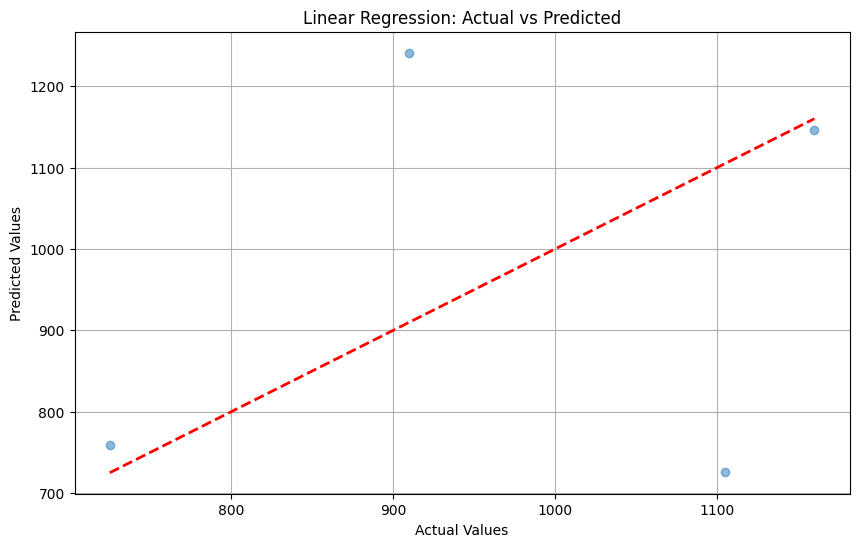

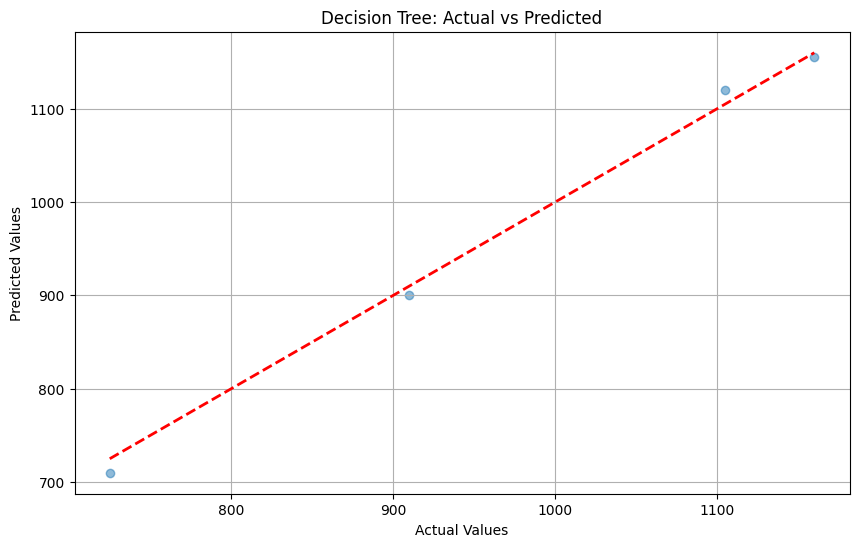

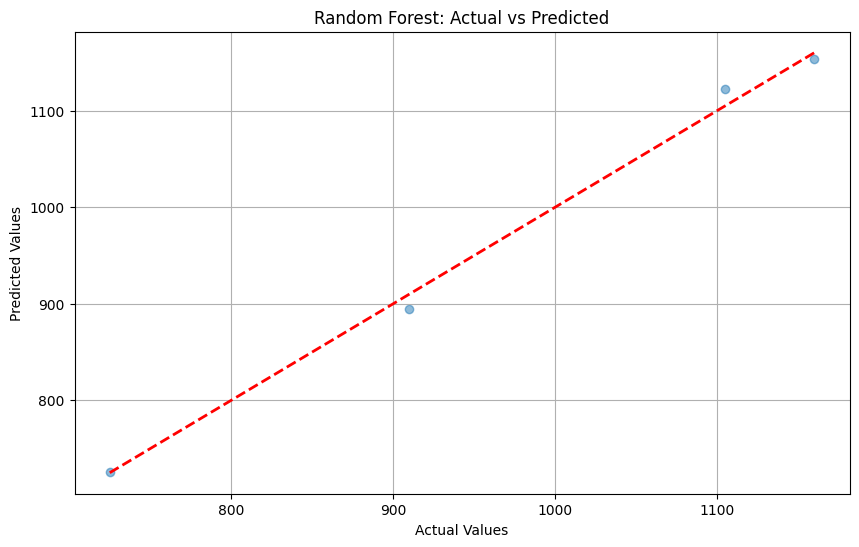

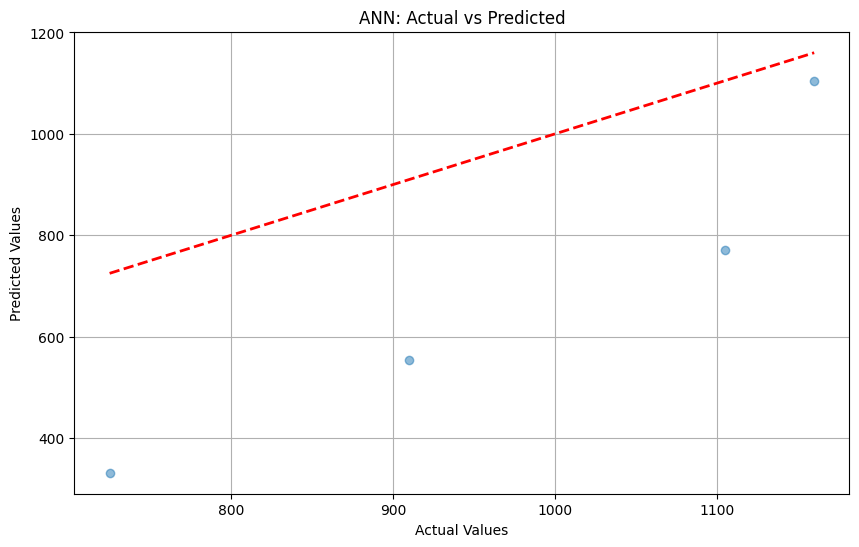

In [ ]:
def plot_actual_vs_predicted(y_true, y_pred, title):
    plt.figure(figsize=(10, 6))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2) # Diagonal line
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(title)
    plt.grid(True)
    plt.show()


plot_actual_vs_predicted(Y_test, y_pred_lr, "Linear Regression: Actual vs Predicted")
plot_actual_vs_predicted(Y_test, dt_pred, "Decision Tree: Actual vs Predicted")
plot_actual_vs_predicted(Y_test, rf_pred, "Random Forest: Actual vs Predicted")
plot_actual_vs_predicted(Y_test, y_pred_ann, "ANN: Actual vs Predicted")

**Comparison**

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
import numpy as np

lr = LinearRegression()
dt = DecisionTreeRegressor(min_samples_split=5, min_samples_leaf=2)
rf = RandomForestRegressor(n_estimators=200, random_state=0)
ann = MLPRegressor(hidden_layer_sizes=(6,6), max_iter=1000) # Increased max_iter

models = {
    "Linear Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "ANN": ann
}

results = {}

for name, model in models.items():

    model.fit(X_train, Y_train)
    y_pred = model.predict(X_test)

    results[name] = {
        "R2": r2_score(Y_test, y_pred),
        "MAE": mean_absolute_error(Y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(Y_test, y_pred)),
        "Predictions": y_pred
    }

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


**R2 Comparison**

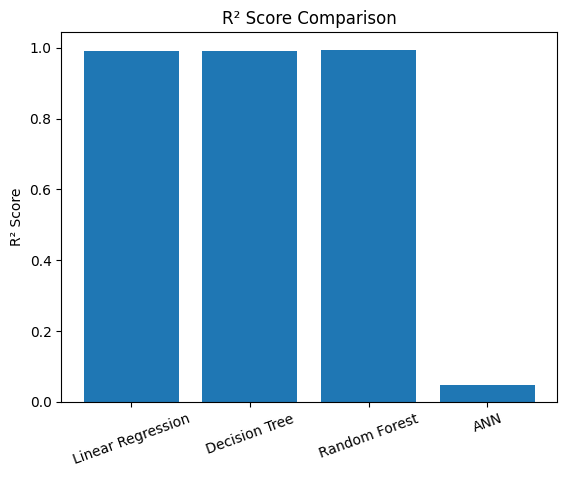

In [ ]:
names = list(results.keys())
r2_scores = [results[m]["R2"] for m in names]

plt.figure()
plt.bar(names, r2_scores)
plt.title("R² Score Comparison")
plt.ylabel("R² Score")
plt.xticks(rotation=20)
plt.show()

**MAE and RMSE comparison**

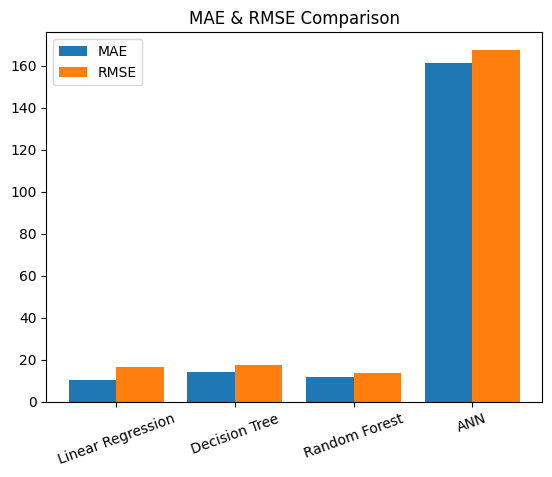

In [ ]:
mae = [results[m]["MAE"] for m in names]
rmse = [results[m]["RMSE"] for m in names]

x = np.arange(len(names))

plt.figure()
plt.bar(x - 0.2, mae, width=0.4, label="MAE")
plt.bar(x + 0.2, rmse, width=0.4, label="RMSE")

plt.xticks(x, names, rotation=20)
plt.title("MAE & RMSE Comparison")
plt.legend()
plt.show()

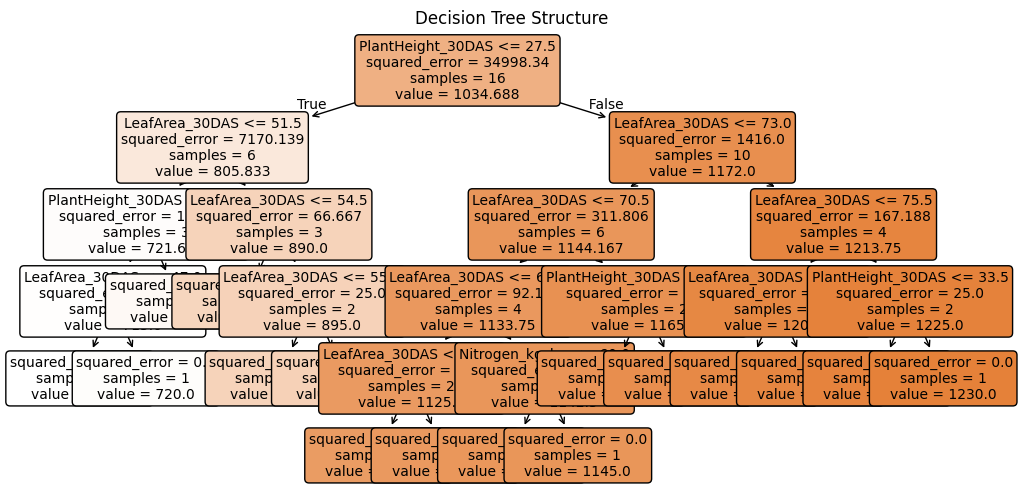

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12,6))
plot_tree(dt_model, feature_names=X.columns, filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree Structure")
plt.show()

***Hyperparameter Tuning for Random forest***

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


rf_model = RandomForestRegressor(n_estimators=10,min_samples_leaf=1,min_samples_split=2,random_state=42)
rf_model.fit(X_train, Y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Results:")
print("MAE:", metrics.mean_absolute_error(Y_test, rf_pred))
print("MSE:", mean_squared_error(Y_test, rf_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(Y_test, rf_pred)))
print("R2 Score:", r2_score(Y_test, rf_pred))

Random Forest Results:
MAE: 14.0
MSE: 229.375
RMSE: 15.14513123086096
R2 Score: 0.9922146796775562


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


rf_model = RandomForestRegressor(n_estimators=50,min_samples_leaf=1,min_samples_split=2,random_state=42)
rf_model.fit(X_train, Y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Results:")
print("MAE:", metrics.mean_absolute_error(Y_test, rf_pred))
print("MSE:", mean_squared_error(Y_test, rf_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(Y_test, rf_pred)))
print("R2 Score:", r2_score(Y_test, rf_pred))

Random Forest Results:
MAE: 11.150000000000034
MSE: 180.3750000000009
RMSE: 13.430376018563326
R2 Score: 0.9938778107764107


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


rf_model = RandomForestRegressor(n_estimators=200,min_samples_leaf=1,min_samples_split=2,random_state=42)
rf_model.fit(X_train, Y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Results:")
print("MAE:", metrics.mean_absolute_error(Y_test, rf_pred))
print("MSE:", mean_squared_error(Y_test, rf_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(Y_test, rf_pred)))
print("R2 Score:", r2_score(Y_test, rf_pred))

Random Forest Results:
MAE: 10.899999999999977
MSE: 170.43874999999952
RMSE: 13.055219262808247
R2 Score: 0.99421506151888


In [ ]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


rf_model = RandomForestRegressor(n_estimators=300,min_samples_leaf=1,min_samples_split=2,random_state=42)
rf_model.fit(X_train, Y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Results:")
print("MAE:", metrics.mean_absolute_error(Y_test, rf_pred))
print("MSE:", mean_squared_error(Y_test, rf_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(Y_test, rf_pred)))
print("R2 Score:", r2_score(Y_test, rf_pred))

Random Forest Results:
MAE: 12.075000000000045
MSE: 197.37263888888975
RMSE: 14.04893728681603
R2 Score: 0.9933008862489983


**Graph for different n_estimator values**

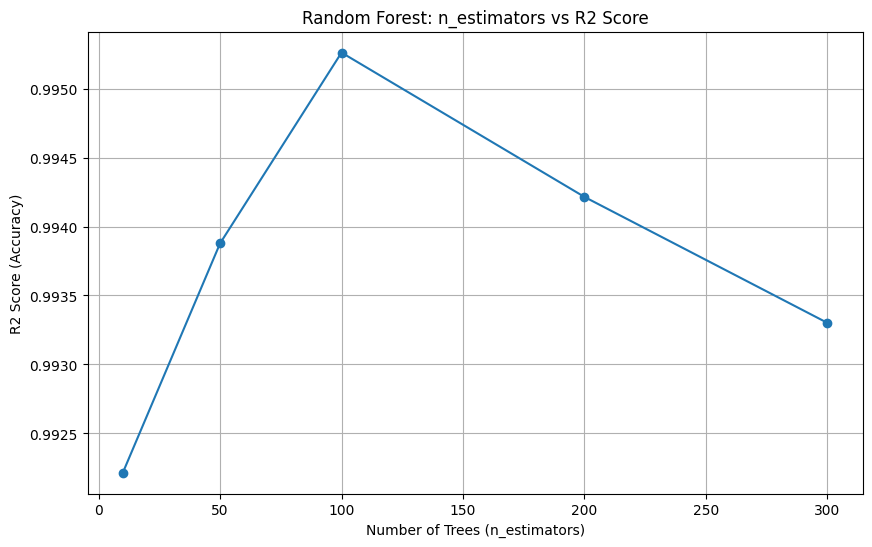

In [ ]:

import matplotlib.pyplot as plt

n_estimators = [10, 50, 100, 200, 300]
accuracy = []

for n in n_estimators:
    rf_model_temp = RandomForestRegressor(n_estimators=n, random_state=42)
    rf_model_temp.fit(X_train, Y_train)
    y_pred_temp = rf_model_temp.predict(X_test)
    accuracy.append(r2_score(Y_test, y_pred_temp))

plt.figure(figsize=(10, 6))
plt.plot(n_estimators, accuracy, marker='o')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('R2 Score (Accuracy)')
plt.title('Random Forest: n_estimators vs R2 Score')
plt.grid(True)
plt.show()